<img src="https://i.ibb.co/93sNcdhp/Logo-pmat-color.png" align="right" width="150">

<br>

# **Laboratorio 0 - Estadística Descriptiva y bases inferenciales**

## **Objetivos de aprendizaje**

Al finalizar este laboratorio, el estudiante pondrá en práctica sus habilidades para:
* Manipular bases de datos reales utilizando librerías de Python.
* Caracterizar una población a través de análisis descriptivo.
* Comparar la distribución observada de los datos con el modelo teórico Normal.
* Comprender la variabilidad muestral mediante simulación.
* Reconocer cómo estos conceptos se conectan con los métodos de inferencia estadística.

## **Recordatorio clave**

Antes de iniciar los contenidos de inferencia es fundamental recordar:
* **Media y Mediana:** describen el comportamiento central de los datos.
* **Desviación estándar:** base del error estándar y variabilidad.
* **Proporciones:** fundamentales para inferencia categórica.
* **Normalidad:** fundamento de las probabilidades, valores críticos y muchos métodos inferenciales.
* **Variabilidad muestral:** las muestras cambian → por eso existe la inferencia.
* **Parámetro vs Estadístico:**

  *Parámetro:* valor desconocido de la población ($\mu$, $\sigma$, $p$).

  *Estadístico:* valor calculado en una muestra ($ \bar{x}$, $s$, $\hat{p}$).

  *Inferencia* = usar un estadístico para estimar un parámetro.
* **Python:** herramienta para cálculo, visualización y simulación.

# **Contexto General**

La Dirección de una Institución de educación superior está desarrollando un análisis descriptivo preliminar para comprender los factores que podrían estar relacionados con el rendimiento académico en asignaturas críticas. Para ello se construyó un dataset de 300 estudiantes de distintas carreras, que contiene las siguientes variables: carrera, nota_certamen, asistencia, satisfaccion, usa_python, horas_estudio, ingreso_anual, sector_laboral, nivel_estudios, promedio_final.

Antes de aplicar métodos inferenciales, es necesario revisar los conocimientos previos fundamentales para interpretar los resultados que se obtendrán a lo largo del semestre.

**Instrucciones**
* Lee atentamente cada contexto y responde las preguntas planteadas.
* Utiliza Python cuando sea necesario para realizar cálculos.
* Algunas preguntas requieren solo análisis conceptual y otras requieren cálculo.
* Descarga el **[dataset](https://docs.google.com/spreadsheets/d/1D76FMmq2SEPDpBkOL4BNsHTQ3LJeMEZJ/export?format=xlsx)** para que puedas cargarlo en tu entorno de trabajo.

In [28]:
import pandas as pd
import glob
from scipy.stats import skew, norm, kurtosis

In [29]:
glob.glob('*')

['G0_A8_variabilidad.xlsx',
 'G0_A2_estudiantes.xlsx',
 'Laboratorio_0_MAT4152.ipynb']

In [30]:
df = pd.read_excel('G0_A2_estudiantes.xlsx')

In [31]:
df.describe()

,nota_certamen,asistencia,satisfaccion,usa_python,horas_estudio,ingreso_anual_US,promedio_final
count,300.000000,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000
mean,5.035000,80.244967,3.136667,0.680000,11.88300,64345.143333,4.962333
std,0.808613,10.671084,1.167275,0.467256,3.64367,26417.589255,1.010024
min,2.600000,54.720000,1.000000,0.000000,5.00000,13120.000000,1.800000
25%,4.500000,73.110000,2.000000,0.000000,9.27500,45256.000000,4.300000
50%,5.100000,80.470000,3.000000,1.000000,11.85000,60180.500000,5.000000
75%,5.600000,87.850000,4.000000,1.000000,14.50000,78691.250000,5.700000
max,7.000000,100.000000,5.000000,1.000000,24.90000,183236.000000,7.000000


In [32]:
var = 'nota_certamen'
diccionario = {
    'Cantidad': df[var].count(),
    'Media': df[var].mean(),
    'Mediana': df[var].median(),
    'DesvStand': df[var].std(),
    'Curtosis': kurtosis(df[var]),
    'Asimetria': skew(df[var]),
    'Moda': df[var].mode(),
    'Min': df[var].min(),
    'P10': df[var].quantile(0.10),
    'P25': df[var].quantile(0.25),
    'P50': df[var].quantile(0.50),
    'P75': df[var].quantile(0.75),
    'P90': df[var].quantile(0.90),
    'Max:': df[var].max(),
    'Aprobados': (df[var] >= 4).mean()*100,
    'Reprobados': (df[var] <= 4).mean()*100
}

pd.DataFrame(diccionario, index=[0])

,Cantidad,Media,Mediana,DesvStand,Curtosis,Asimetria,Moda,Min,P10,P25,P50,P75,P90,Max:,Aprobados,Reprobados
0,300,5.035,5.1,0.808613,-0.193682,-0.217382,5.2,2.6,4.0,4.5,5.1,5.6,6.01,7.0,90.666667,12.666667


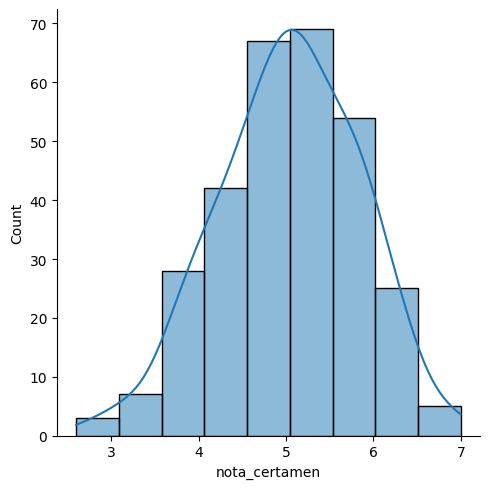

In [33]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sturges = 1 + np.log2(300)

sns.displot(df[var], kde=True, bins=int(sturges))
plt.show()

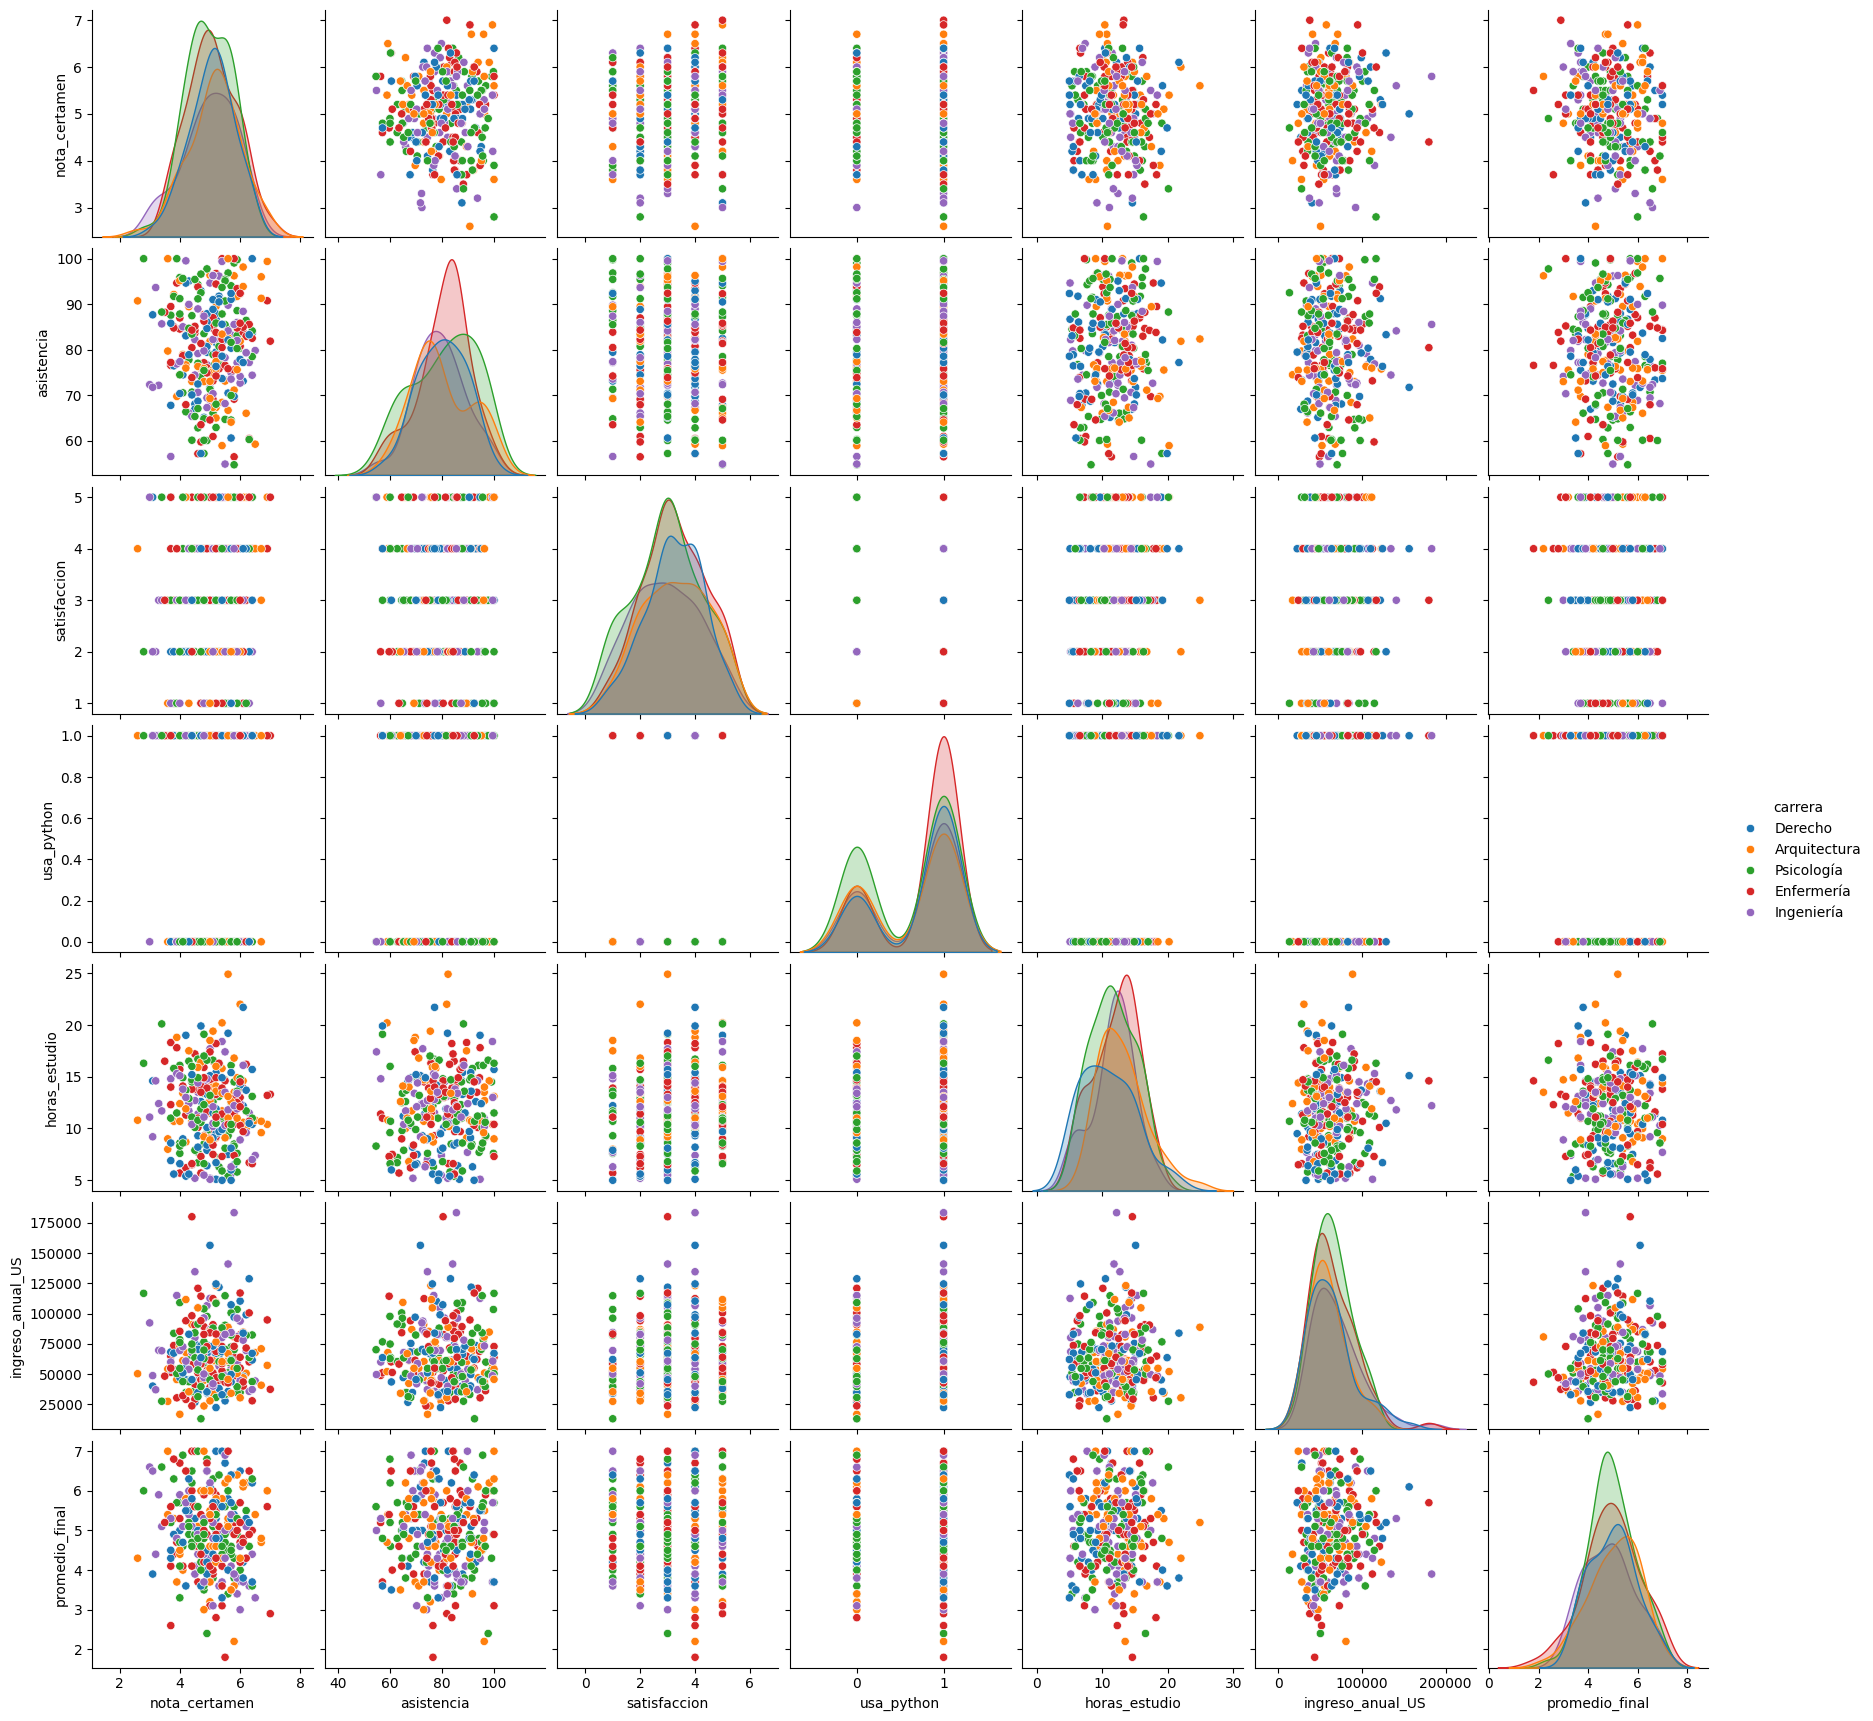

In [34]:
sns.pairplot(df, hue='carrera')

### **Mini-activación diagnóstica**

Antes de avanzar, responde brevemente:

* Clasifica las variables: carrera, ingreso_anual, asistencia.

In [35]:
df.sample(3)

,carrera,nota_certamen,asistencia,satisfaccion,usa_python,horas_estudio,ingreso_anual_US,sector_laboral,nivel_estudios,promedio_final
270,Ingeniería,5.9,85.99,2,0,13.4,96159,Tecnología,Medio,3.8
14,Psicología,4.1,70.53,4,1,14.9,46434,Tecnología,Superior,4.6
194,Ingeniería,5.1,96.30,2,0,10.2,73246,Comercio,Superior,5.2


In [36]:
cols = ['carrera', 'sector_laboral']
df[cols].drop_duplicates(keep='first')

,carrera,sector_laboral
0,Derecho,Salud
1,Arquitectura,Servicios
3,Psicología,Educación
4,Enfermería,Servicios
5,Derecho,Tecnología
6,Enfermería,Comercio
7,Psicología,Salud
8,Psicología,Servicios
9,Ingeniería,Salud
12,Ingeniería,Educación


In [37]:
for col in cols:
    print(df[col].unique())

<StringArray>
['Derecho', 'Arquitectura', 'Psicología', 'Enfermería', 'Ingeniería']
Length: 5, dtype: str
<StringArray>
['Salud', 'Servicios', 'Educación', 'Tecnología', 'Comercio']
Length: 5, dtype: str


Carrera: Variable Cualitativa Nominal con valores unicos ['Derecho' 'Arquitectura' 'Psicología' 'Enfermería' 'Ingeniería']
Ingreso Anual: Variable Cuantitativa Continua
Asistencia: Variable Cuantitativa Continua

* ¿Cuál es la diferencia entre media y mediana?

Ambas con medidas de tendencia central, pero la mediana separa el 50% de los datos (ordenados de menor a mayor) y la media es el promedio de los valores de la variable.|

* ¿Qué significa que la desviación estándar sea alta?

Indica una mayor dispersión de los datos con respecto a la media. Mayor variabilidad y menor homogeneidad.

# **1. Clasificación de variables**

A partir del dataset, clasifica las siguientes variables:

a) Nivel de estudios

b) Ingreso Anual

c) Carrera

d) Promedio Final

# **2. Medidas descriptivas básicas**

2.1. Considera la variable **nota_certamen** del dataset.

a) Calcula la media.


In [38]:
var = 'nota_certamen'
print(f"La media de {var} es {df[var].mean():.2f}")

La media de nota_certamen es 5.04


b) Calcula la mediana.

In [39]:
print(f"La mediana de {var} es {df[var].median():.2f}")

La mediana de nota_certamen es 5.10


c) ¿Estas dos medidas son similares o distintas? ¿Qué sugiere esto del comportamiento de la variable?

**Los valores son muy cercanos, pero la mediana  la derecha de la media indica presencia de valores atípicos en el lado derecho de la variable**

d) Explica qué representaría un valor muy bajo de mediana en este contexto.

**Representaría que más del 50% de los alumnos obtuvo una nota muy baja menor al promedio del curso**

2.2. Usa la variable **asistencia**.

a) Calcula la media y la mediana

In [40]:
var = 'asistencia'
print(f"La media de {var} es {df[var].mean():.2f}")
print(f"La mediana de {var} es {df[var].median():.2f}")

La media de asistencia es 80.24
La mediana de asistencia es 80.47


b) Compara ambos valores y explica qué implicaría una mediana muy alta en este contexto.

**Los valores son muy cercanos, pero si la mediana fuese muy alta, indicaría presencia de valores atípicos, señalando que más del 50% de los alumnos tuvo muy buena asistencia**

# **3. Dispersión del rendimiento**

3.1. Considera nuevamente la variable **nota_certamen**.

a) Calcula la desviación estándar muestral.

In [41]:
var = 'nota_certamen'
print(f"La desviación estándar muestral de {var} es {df[var].std():.2f}")

La desviación estándar muestral de nota_certamen es 0.81


In [42]:
df[var].std() / df[var].mean()

np.float64(0.16059835355929453)

b) Interpreta el resultado en el contexto del rendimiento académico.

**La desviación estandar es baja respecto a la media lo que nos indica que los datos tienen baja variabilidad y por ende una alta homogeneidad**

3.2. Usa la variable **horas_estudio**.

a) Calcula la desviación estándar.

In [43]:
var = 'horas_estudio'
print(f"La desviación estándar de {var} es {df[var].std():.2f}")

La desviación estándar de horas_estudio es 3.64


In [44]:
rango = df[var].max() - df[var].min()
print(f"El rango de {var} es {rango}")

El rango de horas_estudio es 19.9


b) Interpreta la desviación estándar considerando el rango de los datos e indica si los estudiantes estudian de manera homogénea o muy diferente entre sí.

In [45]:
df[var].std() / rango

np.float64(0.18309900213345415)

**Existe una variabilidad que se comporta de forma homogenea respecto al rango de horas de estudio**

# **4. Proporciones y probabilidad simple**

4.1 Usando la variable `usa_python`:

En la base de datos, la variable `usa_python` está codificada como: 1 = usa Python y 0 = no usa Python.

a) Estima la proporción de estudiantes que utilizan Python.

In [46]:
var = 'usa_python'
df[var].sum() / df[var].count()

np.float64(0.68)

In [47]:
f1 = df[var] == 1
prop = f1.mean()
print(f"La proporción de estudiantes que usa Python es {prop*100:.0f}%")

La proporción de estudiantes que usa Python es 68%


b) Interpreta qué significa esa proporción para la asignatura.

**El 68% de los estudiantes utiliza Python**

c) ¿Cuál es la probabilidad de seleccionar un estudiante que no usa Python?

In [48]:
f1 = df[var] == 1
prop = (~f1).mean()
print(f"La proporción de seleccionar un estudiante que no usa Python es {prop*100:.0f}%")

La proporción de seleccionar un estudiante que no usa Python es 32%


4.2. Usa la variable `satisfaccion`.

a) Calcula la proporción de estudiantes que están en niveles de satisfacción 4 o 5. Considera que el nivel de satisfacción se mide desde 1 a 5.

In [49]:
var = 'satisfaccion'
f1 = df[var] >= 4
prop = f1.mean()
print(f"La proporción de estudiantes con satisfacción entre 4 y 5 es {prop*100:.1f}%")

La proporción de estudiantes con satisfacción entre 4 y 5 es 38.3%


b) Interprétalo para la institución.

**El 38.33% delos estudiantes está satisfecho o muy satisfecho con la institución**

c) Calcula la probabilidad de seleccionar un estudiante con satisfacción menor o igual a 2.

In [50]:
# Agrupaciones
# df.groupby(grupos)[var].agg(funciones)
var = 'satisfaccion'
f1 = df[var] <= 2
prop = f1.mean()
print(f"La proporcion de estudiantes con satisfacción menor o igual a 2 es {prop*100:.2f}%")

La proporcion de estudiantes con satisfacción menor o igual a 2 es 29.33%


# **5. Evaluación descriptiva del desempeño final**

5.1 Usa la variable `horas_estudio`:

a) Calcula asimetría y curtosis.

In [51]:
var = 'horas_estudio'
print(f"El coeficiente de asimetria es {skew(df[var]):.2f} y la curtosis es {kurtosis(df[var]):.2f}")

El coeficiente de asimetria es 0.23 y la curtosis es -0.07


b) Calcula las medidas de tendencia central.

In [52]:
diccionario = {
    'Media': df[var].mean(),
    'Mediana': df[var].median(),
    'Moda': df[var].mode()
}
pd.DataFrame(diccionario)

,Media,Mediana,Moda
0,11.883,11.85,10.7


c) Construye el histograma para la variable.

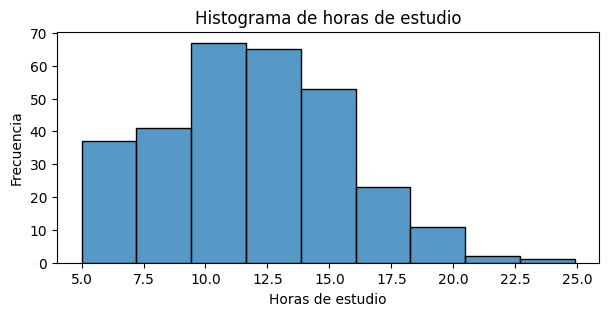

In [53]:
plt.figure(figsize=(7,3))
sns.histplot(df[var], bins= 9)
plt.title("Histograma de horas de estudio")
plt.xlabel("Horas de estudio")
plt.ylabel("Frecuencia")
plt.show()

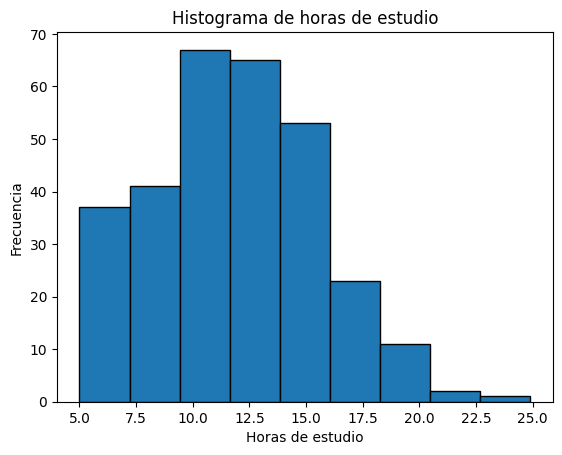

In [54]:
plt.hist(df[var], bins=9, edgecolor='black')
plt.title("Histograma de horas de estudio")
plt.xlabel("Horas de estudio")
plt.ylabel("Frecuencia")
plt.show()

c) ¿La distribución de horas de estudio es aproximadamente simétrica?

**Si, ya que tenemos un coeficiente de asimetria 0.22 dentro de los rangos normales [-0.5, 0.5]**

5.2. Usa la variable `promedio_final`.

a) La variable que se describe, ¿se distribuye normalmente? ¿Por qué? Justifique analizando las medidas de distribución, el gráfico correspondiente y las medidas de tendencia central.

**La variable promedio_final si distribuye normal, ya que sis medidas de tendencia central son cercanas y la curtosis y coeficiente de asimétria se encuentra en rangos normales (entre -05 y 0.5)**

In [55]:
var = 'promedio_final'
diccionario = {
    'Media': df[var].mean(),
    'Mediana': df[var].median(),
    'Moda': df[var].mode(),
    'Curtosis': kurtosis(df[var]),
    'Asimetria': skew(df[var])
}
pd.DataFrame(diccionario)

,Media,Mediana,Moda,Curtosis,Asimetria
0,4.962333,5.0,5.3,-0.243038,-0.091815


# **6. Distrubución normal**


6.1. Asumiendo que la variable `promedio_final` distribuye aproximadamente normal, determine:

a) ¿Cuál es la probabilidad de que un estudiante obtenga un promedio final mayor a 5,5?

In [56]:
# Si no distribuye normal, se calcularia como:
var = 'promedio_final'
f1 = df[var] > 5.5
prop = f1.mean()
print(f"La probabilidad de que un estudiante obtenga un promedio final mayor a 5,5 es {prop*100:.2f}%")

La probabilidad de que un estudiante obtenga un promedio final mayor a 5,5 es 28.67%


In [57]:
# Si distribuye normal, se calcula como:
media = df[var].median()
desv = df[var].std()
(1 - norm.cdf(5.5, media, desv))*100

np.float64(31.028673143618736)

b) ¿Cuál es la probabilidad de que un estudiante obtenga un promedio final menos a 4,0?

In [58]:
p = norm.cdf(4, media, desv)*100
print(f"La probabilidad de que un estudiante obtenga nota menor a 4 es {(1 - p):.2f}%")

La probabilidad de que un estudiante obtenga nota menor a 4 es -15.11%


c) ¿Cuál es la probabilidad de que un estudiante obtenga un promedio final entre a 4,5 y 6,5?

In [59]:
p = norm.cdf(6.5, media, desv) - norm.cdf(4.5, media, desv)
print(f"Hay un {p*100:.2f}% probabilidad de que un estudiante obtenga nota entre 4.5 y 6.5")

Hay un 62.10% probabilidad de que un estudiante obtenga nota entre 4.5 y 6.5


6.2. Asumiendo que la variable `horas_estudio` distribuye aproximadamente normal, determine su media y desviación estándar. Luego, responda las preguntas indicadas.

In [60]:
import pandas as pd
from scipy.stats import skew, kurtosis, norm

df = pd.read_excel('G0_A2_estudiantes.xlsx')
var = 'horas_estudio'

media = df[var].median(),
desv = df[var].std(),
curtosis = kurtosis(df[var]),
asimetria = skew(df[var])
print(f"La media es {media} y la desviación estandar es {desv}")

La media es (np.float64(11.850000000000001),) y la desviación estandar es (np.float64(3.643670142455737),)


a) ¿Cuál es la probabilidad de que un estudiante dedique menos de 10 horas a estudiar?

In [61]:
p = norm.cdf(10, diccionario['media'], diccionario['desv'])*100
print(f"La probabilidad de que un estudiante dedique menos de 10 horas a estudiar es de {p}%")

KeyError: 'media'

b) ¿Cuál es la probabildiad de que un estudiante dedique entre 15 y 20 horas a estudiar?

In [62]:
p = norm.cdf(20, media, desv)*100 - norm.cdf(15, media, desv)*100
print(f"La probabilidad de que un estudiante dedique entre 15 y 20 horas a estudiar es de {p}%") 
# libreria autogluon investigar

La probabilidad de que un estudiante dedique entre 15 y 20 horas a estudiar es de [18.10019312]%


c) ¿Cuál es la probabilidad de que un estudiante dedique más de 11 horas a estudiar?

In [63]:
p = norm.cdf(11, media, desv)*100
print(f"La probabilidad de que un estudiante dedique mas de 11 horas a estudiar es de {1 - p}%")

La probabilidad de que un estudiante dedique mas de 11 horas a estudiar es de [-39.77715007]%


# **7. Comparación de grupos**

7.1 Divide los estudiantes según la variable `usa_python`:

a) Calcula la desviación estándar, la media y el coeficiente de variación de `horas_estudio` en ambos grupos.



In [64]:
group = 'usa_python'
var = 'horas_estudio'
df_group = df.groupby(group)[var].agg(media='mean', desv='std')

df_group['CV%'] = df_group['desv'] / df_group['media'] * 100

df_group

,media,desv,CV%
usa_python,,,
0,11.806250,3.560184,30.155076
1,11.919118,3.690405,30.962067


b) Describe e interpreta las diferencias observadas entre ambos grupos, considerando la media y el coeficiente de variación de las horas de estudio. ¿Qué sugieren estos resultados sobre los hábitos de estudio de los estudiantes que usan Python y los que no?

** Media: Ambos grupos tienen valores similares, y se podria mencionar que el uso de python respecto a las horas de estudio no es relevante

7.2. Divide a los estudiantes según `nivel_estudios` (Básico / Medio / Superior)

a) Calcula la media, la desviación estándar y el coeficiente de variación de la asistencia para cada nivel de estudios.

In [65]:
grupo = 'nivel_estudios'
var = 'asistencia'
df_group = df.groupby(grupo)[var].agg(media='mean', desv='std')

df_group['CV%'] = (df_group['desv'] / df_group['media'])*100

df_group

,media,desv,CV%
nivel_estudios,,,
Básico,80.840385,8.667607,10.721877
Medio,80.073907,10.540174,13.163057
Superior,80.329106,11.268247,14.027602


b) Describe e interpreta las diferencias observadas entre los niveles de estudios

**En términos de Media no existe una diferencia relevante, por ende en los 3 grupos se aprecia un comportamiento similar en el promedio de asistencia.**

**Respecto a la dispersión se observa que estudiantes de nivel básico presentan una asistencia mas homogenea que el resto de niveles, lo cual es confirmaro por el CV%**

# **8. Variabilidad muestral**

En estadística inferencial, la variabilidad muestral explica por qué las estimaciones pueden cambiar cuando se trabaja con distintas muestras extraídas de una misma población.

Para explorar este concepto, trabajaremos con la variable `promedio_final`.

Descarga **[aquí](https://docs.google.com/spreadsheets/d/1axWLVym_wXsVSjKl0saE7-T3hGycdJ8Y/export?format=xlsx)** el dataset que contiene 100 muestras, cada una de tamaño $n=20$, obtenidas a partir del dataset original.

a) Carga el archivo con las 100 muestras.

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Muestreo: np.random.choice(variable, tamaño)
# Semilla: np.random.seed(valor)
# Generar datos normales: np.random.normal(media, desv, tamaño)

df = pd.read_excel('G0_A2_estudiantes.xlsx')
df_muestra = pd.read_excel('G0_A8_variabilidad.xlsx')
df_muestra

,muestra_1,muestra_2,muestra_3,muestra_4,muestra_5,muestra_6,muestra_7,muestra_8,muestra_9,muestra_10,...,muestra_91,muestra_92,muestra_93,muestra_94,muestra_95,muestra_96,muestra_97,muestra_98,muestra_99,muestra_100
0,5.7,4.3,6.0,5.8,6.3,5.6,4.0,3.4,4.0,4.9,...,6.0,5.1,6.0,5.9,4.4,4.7,3.5,5.0,3.7,6.1
1,3.8,4.6,6.7,5.4,5.1,4.0,4.9,5.4,5.3,4.9,...,4.8,6.0,4.8,4.9,5.1,4.4,5.1,2.6,4.2,5.3
2,5.2,6.0,3.7,5.7,3.7,5.6,4.8,6.0,3.1,5.6,...,7.0,6.3,5.4,4.8,5.8,2.8,5.4,4.4,3.6,3.3
3,4.2,6.5,4.4,4.7,5.0,4.4,6.5,3.5,4.3,7.0,...,5.3,4.9,3.0,4.4,4.8,4.7,3.1,6.2,3.7,4.4
4,4.6,4.7,5.9,4.1,3.4,5.4,4.9,4.7,5.6,4.6,...,6.0,4.3,3.3,5.1,3.3,4.3,1.8,5.1,4.2,4.6
5,5.7,4.0,4.8,6.0,4.2,5.7,4.5,5.3,4.3,5.1,...,4.6,6.8,6.3,4.8,4.1,4.8,4.8,5.8,4.8,4.4
6,5.7,3.8,6.3,6.7,3.6,3.5,5.2,4.8,6.3,5.7,...,6.1,4.9,6.5,7.0,5.0,5.8,6.3,4.4,4.3,5.6
7,4.4,5.4,7.0,4.3,5.8,4.9,3.9,5.0,4.5,4.1,...,6.5,4.6,5.4,5.0,4.5,3.4,5.6,4.8,4.9,4.4
8,4.3,5.4,6.0,5.9,5.7,4.6,4.5,4.9,4.3,4.3,...,4.4,3.3,4.8,5.8,4.7,6.3,4.0,4.3,6.3,4.3
9,3.8,3.7,4.2,5.8,5.3,3.3,5.8,4.5,6.0,3.6,...,4.8,5.1,5.8,6.8,5.0,5.0,4.9,4.9,5.5,6.1


b) Calcula la media de cada muestra, obteniendo así 100 medias muestrales.

In [67]:
df_medias = df_muestra.mean()
df_medias

muestra_1      4.920
muestra_2      5.025
muestra_3      5.295
muestra_4      5.405
muestra_5      4.950
               ...  
muestra_96     4.885
muestra_97     4.630
muestra_98     4.575
muestra_99     4.560
muestra_100    5.050
Length: 100, dtype: float64

c) Grafica un histograma de las 100 medias muestrales e interpreta su forma.

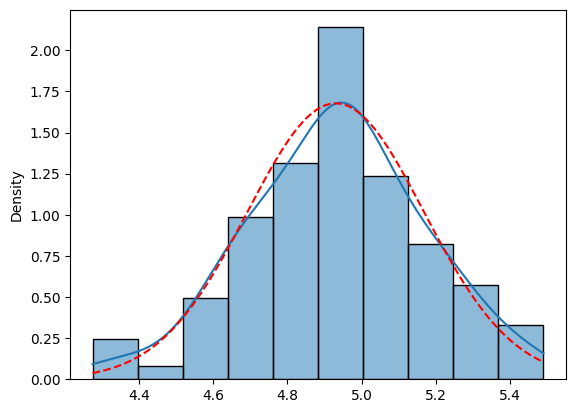

In [68]:
sns.histplot(df_medias, stat='density', kde=True)

x = np.linspace(df_medias.min(), df_medias.max(), 100)

plt.plot(x, norm.pdf(x, df_medias.mean(), df_medias.std()), 'r--')

d) ¿Las medias muestrales son iguales entre sí?

* Las medias muestrales no son iguales entre si. Basta con ver los valores de df_medias

e) Compara la media del curso con el promedio de las 100 medias muestrales.

In [69]:
var = 'promedio_final'
media_curso = df[var].mean()
prom_100_medias = df_medias.mean()

print(f"Media del curso es {media_curso:.4f} y el promedio de las 100 medias muestrales es {prom_100_medias:.4f}")

Media del curso es 4.9623 y el promedio de las 100 medias muestrales es 4.9302


f) ¿A qué atribuyes que estos valores son similares pero no exactamente iguales?

* Tamaño de muestras (n=20) es muy bajo para lograr una igualdad (sobre n=30 se observa igualdad)
* El muestreo pudo haber dejado valores de la población afuera, o haber repetido muchos valores.

# **Con este laboratorio has reforzado los siguientes conceptos:**

* Clasificar variables en un contexto aplicado, identificando correctamente su tipo (cualitativas y cuantitativas) y su rol en el análisis estadístico.
* Calcular e interpretar medidas descriptivas, como la media, la desviación estándar y el coeficiente de variación, para resumir y comprender conjuntos de datos reales.
* Estimar proporciones y probabilidades simples, vinculando los resultados con situaciones concretas y su interpretación en contexto.
* Analizar el comportamiento de una variable con distribución normal, reconociendo sus principales características y su utilidad en la modelación de fenómenos reales.
* Calcular probabilidades, comprendiendo qué tan frecuente o probable es un evento aleatorio.
* Explorar relaciones entre variables, utilizando herramientas descriptivas y gráficas para identificar patrones o asociaciones.
* Introducirte al concepto de variabilidad muestral y comprender su relevancia, entendiendo por qué las estimaciones cambian entre muestras y cómo se relacionan con el valor poblacional.
* Utilizar Python como herramienta de análisis estadístico, aplicándolo para calcular, visualizar e interpretar información de manera eficiente y reproducible.
